[39.01714496] -709.0186449535474
0.9398463339976041
0.824750312331356


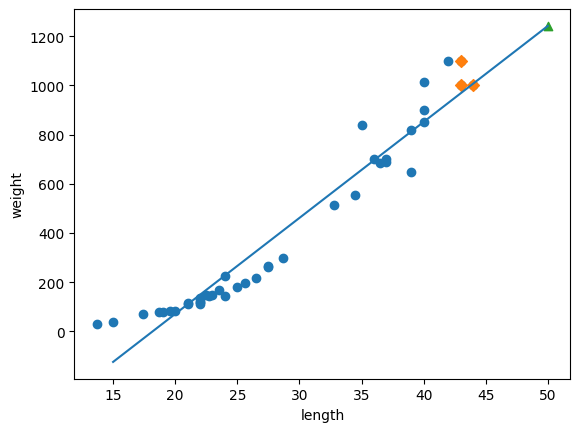

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression


# 최근접 이웃 개수 3 (과대적합[overfitting] 방지)
knr = KNeighborsRegressor(n_neighbors = 3)


lr = LinearRegression()


perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


# 훈련 / 테스트 입력, 목표 데이터 분배
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42)


# 훈련 세트와 타겟 세트 2차원 배열로 변경
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)


# k-최근접 이웃 모델 training
knr.fit(train_input, train_target)


# 선형회귀(Linear Regression) 모델 훈련
lr.fit(train_input, train_target)
print(lr.coef_, lr.intercept_)  # coef(weight) : 가중치 / intercept : 편향

# 훈련 세트 / 테스트 세트 점수
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

# 50cm perch의 최근접 이웃을 구하기
distance, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')    # 훈련 샘플 중 이웃 샘플 그리기
plt.scatter(50, 1241.8, marker='^')     # 50cm perch data를 산점도에 따로 표기
plt.plot([15, 50], [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_])  # 15~50 1차 방정식 그래프
plt.xlabel("length")
plt.ylabel("weight")
plt.show()
